In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import sys,os
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from rois.rois import remove_bad_cells
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import sem
plt.style.use('paper_style.mplstyle')


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
base_dir = '/Volumes/AM_SSD1/Spont2P'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
animals = ['589L',
            '989N',
            '992N',
            '992L',
            '994R',
            '9972R',
            '217R',
            '217N',
            '218L',
            '034R',
            '149L',
            '146R',
            '160R',
            '492N',
            '493R',
            '1912L']
fov_lists = [['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2'],
            ['FOV2'],
            ['FOV1','FOV2'],
            ['FOV1','FOV2'],
            ['FOV1'],
            ['FOV1','FOV2']]
            
info = pd.read_csv(file_key)

get data

In [3]:
pdf = pd.DataFrame()

for a,ani in enumerate(animals):
    df = pd.DataFrame()
    group = info['Group'].loc[info['Animal']==ani].values[0]
    fovs=fov_lists[a]
    for fov in fovs:
        inds = remove_bad_cells(ani,fov,snr_thr=4,file_key=file_key,base_dir=base_dir,suppress_prints=True).copy()
        inds['Animal'] = [ani]*inds.shape[0]
        inds['Group'] = [group]*inds.shape[0]
        df = pd.concat([df,inds],ignore_index=True)

    n_tag_unique_pre = df['Baseline'].loc[(df['Post']==-1)&(df['Tagged']==1)].shape[0]
    n_non_unique_pre = df['Baseline'].loc[(df['Post']==-1)&(df['Tagged']==0)].shape[0]
    p_tag_uni_pre = n_tag_unique_pre/df['Baseline'].loc[df['Post']==-1].shape[0] *100
    p_non_uni_pre = n_non_unique_pre/df['Baseline'].loc[df['Post']==-1].shape[0] *100

    n_tag_unique_post = df['Post'].loc[(df['Baseline']==-1)&(df['Tagged']==1)].shape[0]
    n_non_unique_post = df['Post'].loc[(df['Baseline']==-1)&(df['Tagged']==0)].shape[0]
    p_tag_uni_post = n_tag_unique_post/df['Post'].loc[(df['Baseline']==-1)].shape[0] *100
    p_non_uni_post = n_non_unique_post/df['Post'].loc[(df['Baseline']==-1)].shape[0] *100

    n_tag_reg = df['Baseline'].loc[(df['Baseline']!=-1)&(df['Post']!=-1)&(df['Tagged']==1)].shape[0]
    n_non_reg = df['Baseline'].loc[(df['Baseline']!=-1)&(df['Post']!=-1)&(df['Tagged']==0)].shape[0]
    p_tag_reg = n_tag_reg  / df.loc[(df['Baseline']!=-1)&(df['Post']!=-1)].shape[0] *100
    p_non_reg = n_non_reg  / df.loc[(df['Baseline']!=-1)&(df['Post']!=-1)].shape[0] *100
    #### all cells 
    n_tag_pre = df['Baseline'].loc[(df['Baseline']!=-1)&(df['Tagged']==1)].shape[0]
    n_non_pre = df['Baseline'].loc[(df['Baseline']!=-1)&(df['Tagged']==0)].shape[0]
    n_tag_post = df['Post'].loc[(df['Post']!=-1)&(df['Tagged']==1)].shape[0]
    n_non_post = df['Post'].loc[(df['Post']!=-1)&(df['Tagged']==0)].shape[0]
    
    p_tag_pre = n_tag_pre / df.loc[(df['Baseline']!=-1)].shape[0] *100
    p_non_pre = n_non_pre / df.loc[(df['Baseline']!=-1)].shape[0] *100
    p_tag_post = n_tag_post/ df.loc[(df['Post']!=-1)].shape[0] *100
    p_non_post = n_non_post/ df.loc[(df['Post']!=-1)].shape[0] *100
    
    df_p = pd.DataFrame()
    df_p['Animal'] = [ani]*10
    df_p['Group'] = [group]*10
    df_p['Session'] = ['D0 Only']*2 + ['D4 Only']*2 + ['Both']*2 + ['D0 All']*2 + ['D4 All']*2
    df_p['N cells'] = [n_tag_unique_pre,n_non_unique_pre,n_tag_unique_post,n_non_unique_post,n_tag_reg,n_non_reg,n_tag_pre,n_non_pre,n_tag_post,n_non_post]
    df_p['Percent Cells'] = [p_tag_uni_pre,p_non_uni_pre,p_tag_uni_post,p_non_uni_post,p_tag_reg,p_non_reg,p_tag_pre,p_non_pre,p_tag_post,p_non_post]
    df_p['Tagged'] = ['Engram','Non-engram','Engram','Non-engram','Engram','Non-engram','Engram','Non-engram','Engram','Non-engram']

    pdf = pd.concat([pdf,df_p],ignore_index=True)

356 cells filtered to 256cells
326 cells filtered to 157cells
381 cells filtered to 355cells
368 cells filtered to 224cells
368 cells filtered to 305cells
348 cells filtered to 229cells
461 cells filtered to 343cells
424 cells filtered to 296cells
414 cells filtered to 362cells
390 cells filtered to 259cells
367 cells filtered to 256cells
438 cells filtered to 248cells
374 cells filtered to 247cells
390 cells filtered to 251cells
435 cells filtered to 317cells
373 cells filtered to 298cells
412 cells filtered to 339cells
403 cells filtered to 354cells
457 cells filtered to 229cells
258 cells filtered to 214cells
241 cells filtered to 192cells
277 cells filtered to 238cells
306 cells filtered to 267cells
237 cells filtered to 102cells
239 cells filtered to 184cells
223 cells filtered to 175cells


In [4]:
pdf.to_csv('spont2p_proptag.csv')

Descriptive Stats

In [5]:
sum_cells_fc = pdf.loc[pdf.Group=='FC'].groupby('Session').sum()
sum_cells_hc= pdf.loc[pdf.Group=='HC'].groupby('Session').sum()
sum_cells_fc.drop(['Percent Cells'],axis=1)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3235965860.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sum_cells_fc = pdf.loc[pdf.Group=='FC'].groupby('Session').sum()
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3235965860.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sum_cells_hc= pdf.loc[pdf.Group=='HC'].groupby('Session').sum()


,N cells
Session,
Both,1174
D0 All,2248
D0 Only,1074
D4 All,2366
D4 Only,1192


# Registered Cells

In [6]:
reg = pdf.loc[(pdf['Tagged']=='Engram')&(pdf['Session']=='Both')]
turnover_fchc = pdf[['Animal','Group','Session','Percent Cells']].loc[(pdf['Tagged']=='Engram')&((pdf['Session']=='D4 Only')|(pdf['Session']=='D0 Only'))]

Text(0, 0.5, '% Engram-Tagged')

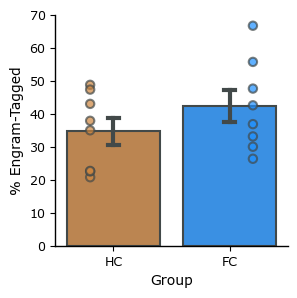

In [7]:

data = pdf.loc[(pdf['Tagged']=='Engram')]

gray='#424949'
colors_group = ['peru','dodgerblue']
fig,ax=plt.subplots(figsize=(3,3))
sb.stripplot(data=data.loc[data.Session=='Both'],x='Group',hue='Group',y='Percent Cells',palette=colors_group,
             edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
sb.barplot(data=data[data.Session=='Both'],x='Group',hue='Group',y='Percent Cells',errorbar='se',
                palette=colors_group,ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.despine()
plt.ylabel('% Engram-Tagged')


In [8]:
print(f"{data['Percent Cells'].loc[(data.Session=='Both')&(data.Group=='HC')].mean():.2f} % Reactivated HC")
print(f"{data['Percent Cells'].loc[(data.Session=='Both')&(data.Group=='FC')].mean():.2f} % Reactivated HC")

34.73 % Reactivated HC
42.36 % Reactivated HC


In [9]:
pg.ttest(data['Percent Cells'].loc[(data.Session=='Both')&(data.Group=='FC')],
         data['Percent Cells'].loc[(data.Session=='Both')&(data.Group=='HC')])

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.205057,14,two-sided,0.248156,"[-5.95, 21.21]",0.602528,0.69,0.202491


Text(0, 0.5, '% Engram-Tagged')

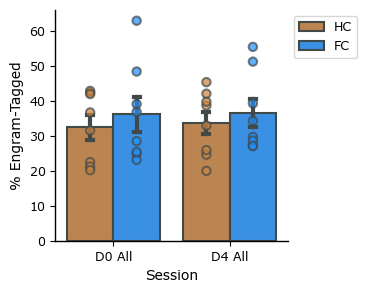

In [10]:
data = pdf[pdf['Session'].isin(['D0 All','D0 All','D4 All','D4 All'])].loc[pdf['Tagged']=='Engram']

gray='#424949'
colors_group = ['peru','dodgerblue']
fig,ax=plt.subplots(figsize=(3,3))
sb.stripplot(data=data,x='Session',hue='Group',y='Percent Cells',palette=colors_group,
             edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
sb.barplot(data=data,x='Session',hue='Group',y='Percent Cells',errorbar='se',
                palette=colors_group,ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.despine()
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('% Engram-Tagged')

In [11]:
pg.normality(data=data)

,W,pval,normal
N cells,0.918163,0.018542,False
Percent Cells,0.947253,0.120399,True


In [12]:
pg.mixed_anova(data=data,dv='Percent Cells',within='Session',between='Group',subject='Animal')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,88.829468,1,14,88.829468,0.364470,0.555690,0.025373,NaN
1,Session,5.816762,1,14,5.816762,0.894756,0.360233,0.060072,1.0
2,Interaction,1.272630,1,14,1.272630,0.195761,0.664923,0.013790,NaN


In [13]:
pg.pairwise_tests(data=data,dv='Percent Cells',within='Session',between='Group',subject='Animal')

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:478: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = data.groupby([subject, f], as_index=False, observed=True, sort=True).mean()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "Parametric"] = parametric


,Contrast,Session,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,Session,-,D0 All,D4 All,True,True,-0.972341,15.0,two-sided,0.346301,0.385,-0.075950
1,Group,-,FC,HC,False,True,0.603714,14.0,two-sided,0.555690,0.484,0.285392
2,Session * Group,D0 All,FC,HC,False,True,0.619029,14.0,two-sided,0.545839,0.487,0.292632
3,Session * Group,D4 All,FC,HC,False,True,0.572780,14.0,two-sided,0.575878,0.478,0.270769


# Turnover Cells 

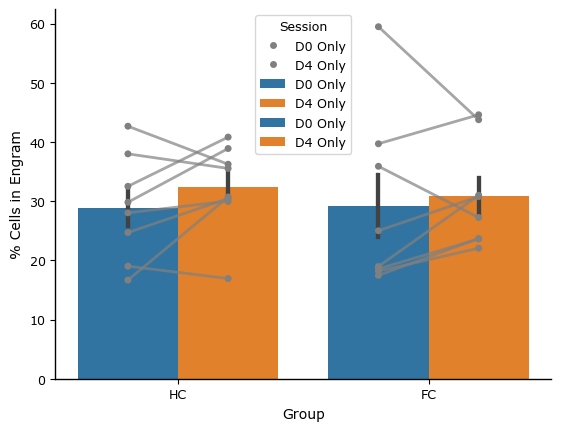

In [14]:
data = pdf[~pdf['Session'].isin(['D0 All', 'D4 All','Both'])].loc[pdf.Tagged=='Engram'] #df of the turning over cells only

sb.stripplot(data=data,hue_order=['D0 Only','D4 Only'],x='Group',hue='Session',y='Percent Cells',dodge=True,palette=['gray','gray'],jitter=False)
sb.barplot(data=data,hue_order=['D0 Only','D4 Only'],x='Group',hue='Session',y='Percent Cells',errorbar='se')
sb.barplot(data=data,hue_order=['D0 Only','D4 Only'],x='Group',hue='Session',y='Percent Cells',errorbar='se')
fc = data.loc[data.Group=='FC']
hc = data.loc[data.Group=='HC']

x1,x2,x3,x4 = -.2,.2,.8,1.2
for ani in np.unique(data['Animal'].values):
    if data['Group'].loc[data['Animal']==ani].values[0]=='HC':
        hcpre = hc['Percent Cells'].loc[(hc['Animal']==ani)&(hc['Session']=='D0 Only')].values[0]
        hcpost = hc['Percent Cells'].loc[(hc['Animal']==ani)&(hc['Session']=='D4 Only')].values[0]
        plt.plot([x1,x2],[hcpre,hcpost],color='gray',alpha=.7)
    if data['Group'].loc[data['Animal']==ani].values[0]=='FC':
        fcpre = fc['Percent Cells'].loc[(fc['Animal']==ani)&(fc['Session']=='D0 Only')].values[0]
        fcpost = fc['Percent Cells'].loc[(fc['Animal']==ani)&(fc['Session']=='D4 Only')].values[0]
        plt.plot([x3,x4],[fcpre,fcpost],color='gray',alpha=.7)
plt.ylabel('% Cells in Engram')
sb.despine()
plt.savefig('prop_cells.svg')

In [15]:
sem_hc_D0 = sem(data['Percent Cells'].loc[(data.Session=='D0 Only')&(data.Group=='HC')])
sem_fc_D0 = sem(data['Percent Cells'].loc[(data.Session=='D0 Only')&(data.Group=='FC')])
sem_hc_D4 = sem(data['Percent Cells'].loc[(data.Session=='D4 Only')&(data.Group=='HC')])
sem_fc_D4 = sem(data['Percent Cells'].loc[(data.Session=='D4 Only')&(data.Group=='FC')])

In [16]:
pg.mixed_anova(data=data,dv='Percent Cells',within='Session',between='Group',subject='Animal')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,3.773150,1,14,3.773150,0.020343,0.888615,0.001451,NaN
1,Session,54.186838,1,14,54.186838,1.653334,0.219367,0.105622,1.0
2,Interaction,6.759253,1,14,6.759253,0.206237,0.656694,0.014517,NaN


In [17]:
pg.pairwise_tests(data=data,dv='Percent Cells',between='Group',within='Session',subject='Animal',parametric=True,padjust='fdr_bh',within_first=False)

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:478: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = data.groupby([subject, f], as_index=False, observed=True, sort=True).mean()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "Parametric"] = parametric


,Contrast,Group,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Group,-,FC,HC,False,True,-0.142629,14.0,two-sided,0.888615,NaN,NaN,0.431,-0.067425
1,Session,-,D0 Only,D4 Only,True,True,-1.321254,15.0,two-sided,0.206217,NaN,NaN,0.534,-0.250949
2,Group * Session,FC,D0 Only,D4 Only,True,True,-0.523084,7.0,two-sided,0.617060,0.617060,fdr_bh,0.377,-0.129498
3,Group * Session,HC,D0 Only,D4 Only,True,True,-1.434115,7.0,two-sided,0.194662,0.389324,fdr_bh,0.722,-0.406175


In [18]:
pg.pairwise_tests(data=data,dv='Percent Cells',between='Group',within='Session',subject='Animal',parametric=True,padjust='fdr_bh',within_first=True)

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:478: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = data.groupby([subject, f], as_index=False, observed=True, sort=True).mean()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "Parametric"] = parametric


,Contrast,Session,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,Session,-,D0 Only,D4 Only,True,True,-1.321254,15.0,two-sided,0.206217,NaN,NaN,0.534,-0.250949
1,Group,-,FC,HC,False,True,-0.142629,14.0,two-sided,0.888615,NaN,NaN,0.431,-0.067425
2,Session * Group,D0 Only,FC,HC,False,True,0.037806,14.0,two-sided,0.970376,0.970376,fdr_bh,0.428,0.017872
3,Session * Group,D4 Only,FC,HC,False,True,-0.392210,14.0,two-sided,0.700809,0.970376,fdr_bh,0.451,-0.185408


In [19]:
pg.normality(data.loc[data['Group']=='FC'])

,W,pval,normal
N cells,0.906602,0.102590,True
Percent Cells,0.889943,0.055588,True


In [20]:
df = pdf[~pdf['Session'].isin(['D4 All','D0 All'])].groupby(['Tagged','Group','Session']).mean().reset_index()
df

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3110595875.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = pdf[~pdf['Session'].isin(['D4 All','D0 All'])].groupby(['Tagged','Group','Session']).mean().reset_index()


,Tagged,Group,Session,N cells,Percent Cells
0,Engram,FC,Both,60.000,42.356375
1,Engram,FC,D0 Only,37.125,29.149963
2,Engram,FC,D4 Only,43.000,30.833342
3,Engram,HC,Both,57.750,34.727062
4,Engram,HC,D0 Only,37.375,28.917538
5,Engram,HC,D4 Only,36.000,32.439293
6,Non-engram,FC,Both,86.750,57.643625
7,Non-engram,FC,D0 Only,97.125,70.850037
8,Non-engram,FC,D4 Only,106.000,69.166658
9,Non-engram,HC,Both,107.875,65.272938


In [21]:
df.to_csv('percent_cells.csv')

In [22]:
df['Percent Cells'].values[0:6]

array([42.35637499, 29.14996281, 30.83334173, 34.72706235, 28.91753801,
       32.43929301])

In [23]:
df['Percent Cells'].values[6:]

array([57.64362501, 70.85003719, 69.16665827, 65.27293765, 71.08246199,
       67.56070699])

In [24]:
x=['D0','D4']
y1=df['Percent Cells'].values[0:6] # engram: both, d0, d4, nonengram: both d0 d4
y2=100-df['Percent Cells'].values[0:6]

In [25]:
from matplotlib import rcParams
rcParams['svg.fonttype']='none'
rcParams['font.family']='Verdana'

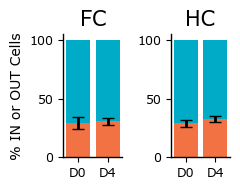

In [26]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize =(2.5,2))
ax[0].bar(x,y1[1:3],color='#F37243')
ax[0].bar(x,y2[1:3],bottom=y1[1:3],color='#00ABC8')
ax[0].errorbar(0,y1[1],yerr=sem_fc_D0,ecolor='k',capsize=4)
ax[0].errorbar(1,y1[2],yerr=sem_fc_D4,ecolor='k',capsize=4)
ax[0].set_title('FC')
ax[0].spines[['right', 'top']].set_visible(False)

ax[1].bar(x,y1[4:],color='#F37243')
ax[1].bar(x,y2[4:],bottom=y1[4:],color='#00ABC8')
ax[1].errorbar(0,y1[4],yerr=sem_hc_D0,ecolor='k',capsize=4)
ax[1].errorbar(1,y1[5],yerr=sem_hc_D4,ecolor='k',capsize=4)
ax[1].set_title('HC')
ax[1].spines[['right', 'top']].set_visible(False)

ax[0].set_ylabel('% IN or OUT Cells')
# ax[0].text(.5,102,'***',ha='center')
# ax[0].plot([0,1],[103,103],color='k',lw=1)
# ax[1].text(.5,102,'*',ha='center',size=9)
# ax[1].plot([0,1],[103,103],color='k',lw=1)

plt.tight_layout()
plt.savefig('Fig1Fprop_drifty_cells.svg',transparent=True)


In [27]:
data1 = pdf[~pdf['Session'].isin(['D0 All','D4 All','Both'])].loc[(pdf['Tagged']=='Engram')]
pg.normality(data=data1)

,W,pval,normal
N cells,0.902891,0.007343,False
Percent Cells,0.944814,0.102606,True


In [28]:
palette=['#00ABC8','#F37243']

In [29]:
data

,Animal,Group,Session,N cells,Percent Cells,Tagged
0,589L,HC,D0 Only,31,29.807692,Engram
2,589L,HC,D4 Only,42,38.888889,Engram
10,989N,FC,D0 Only,77,39.690722,Engram
12,989N,FC,D4 Only,70,44.585987,Engram
20,992N,FC,D0 Only,24,25.000000,Engram
22,992N,FC,D4 Only,32,30.769231,Engram
30,992L,HC,D0 Only,13,32.500000,Engram
32,992L,HC,D4 Only,20,40.816327,Engram
40,994R,HC,D0 Only,90,42.654028,Engram
42,994R,HC,D4 Only,75,36.231884,Engram


In [30]:
sem_hc_reg = sem(pdf['Percent Cells'].loc[(pdf.Session=='Both')&(pdf.Group=='HC')])
sem_fc_reg = sem(pdf['Percent Cells'].loc[(pdf.Session=='Both')&(pdf.Group=='FC')])


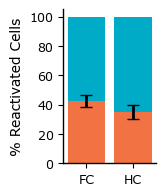

In [31]:

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(1.2,2))
ax.bar(['FC','HC'],[y1[0],y1[3]],color='#F37243')
ax.bar(['FC','HC'],[y2[0],y2[3]],bottom=[y1[0],y1[3]],color='#00ABC8')
plt.errorbar(0,y1[0],yerr=sem_fc_reg,ecolor='k',capsize=4)
plt.errorbar(1,y1[3],yerr=sem_hc_reg,ecolor='k',capsize=4)
ax.set_ylabel('% Reactivated Cells')
ax.spines[['right', 'top']].set_visible(False)
plt.savefig('Fig1G_prop_stablecells.svg',transparent=True)


In [32]:
data2 = pdf.loc[(pdf['Tagged']=='Engram')&(pdf['Session']=='Both')]


In [33]:
pg.normality(data=data2)

,W,pval,normal
N cells,0.928150,0.227846,True
Percent Cells,0.961329,0.685967,True


In [34]:
pg.ttest(data2['Percent Cells'].loc[data2.Group=='FC'],data2['Percent Cells'].loc[data2.Group=='HC'])

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.205057,14,two-sided,0.248156,"[-5.95, 21.21]",0.602528,0.69,0.202491


# Of engram cells, what are the proportion of in, reactivated and out

In [35]:
edf = pd.DataFrame()
for a,ani in enumerate(animals):
    df = pd.DataFrame()
    group = info['Group'].loc[info['Animal']==ani].values[0]
    fovs=fov_lists[a]
    for fov in fovs:
        inds = remove_bad_cells(ani,fov,snr_thr=4,file_key=file_key,base_dir=base_dir)
        inds['Animal'] = [ani]*inds.shape[0]
        inds['Group'] = [group]*inds.shape[0]
        df = pd.concat([df,inds],ignore_index=True)

    df_tag = df.loc[(df['Tagged']==1)]
    n_tag_all = df_tag.shape[0]
    n_tag_in = df_tag.loc[df_tag['Baseline']==-1].shape[0]
    n_tag_out = df_tag.loc[df_tag['Post']==-1].shape[0]
    n_tag_both = df_tag.loc[(df_tag['Baseline']!=-1)&(df_tag['Post']!=-1)].shape[0]
    
    n_turnover = df.shape[0]-df.loc[(df['Baseline']!=-1) & (df['Post']!=-1)].shape[0]
    n_tag_turnover = df_tag.shape[0]-df_tag.loc[(df_tag['Baseline']!=-1) & (df_tag['Post']!=-1)].shape[0]
    
    df_p = pd.DataFrame()
    df_p['Animal'] = [ani]*4
    df_p['Session'] = ['D0 Only']+['Both']+['D4 Only']+['Turnover Cells']
    df_p['Group'] = [group]*4
    df_p['N cells'] = [n_tag_out,n_tag_both,n_tag_in,n_tag_turnover]
    df_p['Percent Cells'] = [n_tag_out/n_tag_all,n_tag_both/n_tag_all,n_tag_in/n_tag_all,n_tag_turnover/n_turnover]

    edf = pd.concat([edf,df_p],ignore_index=True)


356 cells filtered to 256cells


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Animal'] = [ani]*inds.shape[0]
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Group'] = [group]*inds.shape[0]


326 cells filtered to 157cells


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Animal'] = [ani]*inds.shape[0]
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Group'] = [group]*inds.shape[0]


381 cells filtered to 355cells


...

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Animal'] = [ani]*inds.shape[0]
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Group'] = [group]*inds.shape[0]


239 cells filtered to 184cells


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Animal'] = [ani]*inds.shape[0]
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Group'] = [group]*inds.shape[0]


223 cells filtered to 175cells


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Animal'] = [ani]*inds.shape[0]
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_28754/3790885524.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds['Group'] = [group]*inds.shape[0]


In [36]:
turnover = edf.loc[edf['Session']=='Turnover Cells']

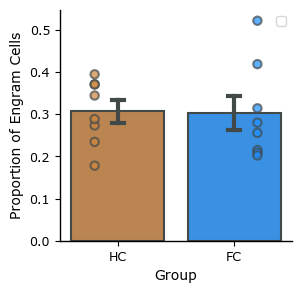

In [37]:
fig,ax=plt.subplots(figsize=(3,3))
sb.barplot(data=turnover,x='Group',hue='Group',y='Percent Cells',palette=colors_group,errorbar='se',
           ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.stripplot(data=turnover,x='Group',hue='Group',y='Percent Cells',palette=colors_group,
            edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
plt.ylabel('Proportion of Engram Cells')
sb.despine()
plt.legend(bbox_to_anchor=(1,1))

In [38]:
edf.head()

,Animal,Session,Group,N cells,Percent Cells
0,589L,D0 Only,HC,31,0.181287
1,589L,Both,HC,98,0.573099
2,589L,D4 Only,HC,42,0.245614
3,589L,Turnover Cells,HC,73,0.344340
4,989N,D0 Only,FC,77,0.281022


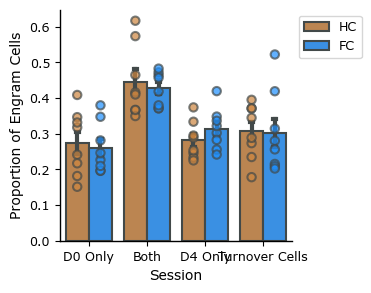

In [39]:
fig,ax=plt.subplots(figsize=(3,3))
sb.barplot(data=edf,x='Session',hue='Group',y='Percent Cells',palette=colors_group,errorbar='se',
           ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.stripplot(data=edf,x='Session',hue='Group',y='Percent Cells',palette=colors_group,
            edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
plt.ylabel('Proportion of Engram Cells')
sb.despine()
plt.legend(bbox_to_anchor=(1,1))

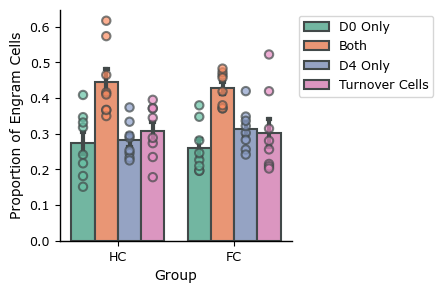

In [40]:
fig,ax=plt.subplots(figsize=(3,3))
sb.barplot(data=edf,hue='Session',x='Group',y='Percent Cells',palette='Set2',errorbar='se',
           ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.stripplot(data=edf,hue='Session',x='Group',y='Percent Cells',palette='Set2',
            edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
plt.ylabel('Proportion of Engram Cells')
sb.despine()
plt.legend(bbox_to_anchor=(1,1))

In [41]:
turnover_e = edf.loc[edf['Session'].isin(['D0 Only','D4 Only'])]
turnover_e.head()

,Animal,Session,Group,N cells,Percent Cells
0,589L,D0 Only,HC,31,0.181287
2,589L,D4 Only,HC,42,0.245614
4,989N,D0 Only,FC,77,0.281022
6,989N,D4 Only,FC,70,0.255474
8,992N,D0 Only,FC,24,0.226415


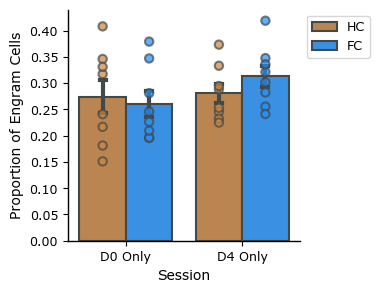

In [42]:
fig,ax=plt.subplots(figsize=(3,3))
sb.barplot(data=turnover_e,x='Session',hue='Group',y='Percent Cells',palette=colors_group,errorbar='se',
           ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.stripplot(data=turnover_e,x='Session',hue='Group',y='Percent Cells',palette=colors_group,
            edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
plt.ylabel('Proportion of Engram Cells')
sb.despine()
plt.legend(bbox_to_anchor=(1,1))

In [43]:
turnover_e.head()

,Animal,Session,Group,N cells,Percent Cells
0,589L,D0 Only,HC,31,0.181287
2,589L,D4 Only,HC,42,0.245614
4,989N,D0 Only,FC,77,0.281022
6,989N,D4 Only,FC,70,0.255474
8,992N,D0 Only,FC,24,0.226415


In [44]:
pg.mixed_anova(data=turnover_e,
               dv='Percent Cells',
               between='Group',
               within='Session',
               subject='Animal')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,0.000677,1,14,0.000677,0.220842,0.645635,0.015529,NaN
1,Session,0.007107,1,14,0.007107,1.111759,0.309558,0.073569,1.0
2,Interaction,0.004306,1,14,0.004306,0.673571,0.425564,0.045904,NaN


In [45]:
pg.pairwise_tests(data=turnover_e,
               dv='Percent Cells',
               between='Group',
               within='Session',
               within_first=False,
               subject='Animal')

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:478: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = data.groupby([subject, f], as_index=False, observed=True, sort=True).mean()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "Parametric"] = parametric


,Contrast,Group,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,Group,-,FC,HC,False,True,0.469938,14.0,two-sided,0.645635,0.461,0.222153
1,Session,-,D0 Only,D4 Only,True,True,-1.066063,15.0,two-sided,0.303254,0.416,-0.429367
2,Group * Session,FC,D0 Only,D4 Only,True,True,-1.267644,7.0,two-sided,0.245462,0.621,-0.786073
3,Group * Session,HC,D0 Only,D4 Only,True,True,-0.173605,7.0,two-sided,0.867090,0.341,-0.085056


In [46]:
in_e = edf.loc[edf['Session']=='D4 Only']

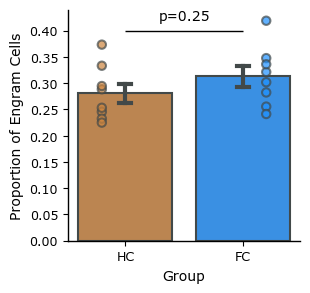

In [47]:
fig,ax=plt.subplots(figsize=(3,3))
sb.barplot(data=in_e,x='Group',hue='Group',y='Percent Cells',palette=colors_group,errorbar='se',
           ax=ax,capsize=.1,linewidth=1.5,edgecolor=gray,err_kws={'color':gray})
sb.stripplot(data=in_e,x='Group',hue='Group',y='Percent Cells',palette=colors_group,
            edgecolor=gray, linewidth=1.5, dodge=True,jitter=0, alpha=.7, size=6,legend=False,ax=ax)
plt.ylabel('Proportion of Engram Cells')
plt.hlines(.4,0,1,colors='k',linewidth=1)
plt.text(.5,.42,'p=0.25',ha='center')

sb.despine()


In [48]:
pg.normality(in_e)

,W,pval,normal
N cells,0.926316,0.213009,True
Percent Cells,0.947944,0.457828,True


In [49]:
pg.ttest(in_e['Percent Cells'].loc[in_e['Group']=='FC'],
         in_e['Percent Cells'].loc[in_e['Group']=='HC'],paired=False)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.188592,14,two-sided,0.254372,"[-0.03, 0.09]",0.594296,0.682,0.198263


# Tone FC Mice

In [50]:
import os 
from utilities import animal
import ast

In [51]:
base_dir = '/Users/amonast/Desktop/Tone2P'
file_key = os.path.join(base_dir,'Data_info_TFC.csv')
mice_d4 = ['639N','997B','939L','M1N','M2L','M5L','F5L','F7N','194L','M8BL2','M9BR2']
mice_reg = [m for m in mice_d4 if ('M5L' not in m) &('F5L' not in m)]

In [52]:
rows=[]
for a in mice_d4:
    mouse = animal.animal(a,'FOV1',file_key,base_dir)
    traces = mouse.load_traces(sessions=['Recall1'])
    columns = traces.columns[1:]
    is_engram = columns.map(lambda x: ast.literal_eval(x)[0]).values
    prop_e = is_engram.sum() / len(is_engram) *100
    rows.append(pd.DataFrame({'animal':[a],
                              'session':['D4'],
                              'prop_engram':prop_e}))
pdf1 = pd.concat(rows,ignore_index=True)

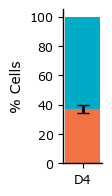

In [53]:
y = pdf1['prop_engram'].mean()
sem = pdf1['prop_engram'].sem()
y2 = (100 - pdf1['prop_engram']).mean()

fig, ax = plt.subplots(figsize=(.5,2))
ax.bar(['D4'], [y], color='#F37243')
ax.bar(['D4'], [y], color='#F37243')
ax.bar(['D4'], [y2], bottom=[y], color='#00ABC8')
ax.errorbar(0, y, yerr=sem, ecolor='k', capsize=4)
ax.set_ylabel('% Cells')
ax.spines[['right', 'top']].set_visible(False)

# % Reactivated Cells

In [54]:
rows=[]
rows2 = []
for a in mice_reg:
    mouse = animal.animal(a,'FOV1',file_key,base_dir)
    traces = mouse.load_traces(sessions=['Baseline','Recall1'])
    # Both cells 
    cell_reg = mouse.load_cellreg()
    cell_reg = cell_reg.loc[cell_reg['Score']!=3]
    n_reg = cell_reg.loc[(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].shape[0]
    n_eng = cell_reg.loc[(cell_reg['Tagged']==1)&(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].shape[0]
    prop_e_both = (n_eng/n_reg)*100
    n_non = cell_reg.loc[(cell_reg['Tagged']==0)&(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].shape[0]
    prop_n_both = (n_non/n_reg)*100

    # unique cell totals (correct denominators)
    n_d0_only = cell_reg.loc[(cell_reg['Recall1']==-1)&(cell_reg['Baseline']!=-1)].shape[0]
    n_d4_only = cell_reg.loc[(cell_reg['Baseline']==-1)&(cell_reg['Recall1']!=-1)].shape[0]

    # OUT cells (D0 Only)
    out_E = cell_reg.loc[(cell_reg['Tagged']==1)&(cell_reg['Recall1']==-1)&(cell_reg['Baseline']!=-1)].shape[0]
    prop_e_out = (out_E / n_d0_only)*100
    out_N = cell_reg.loc[(cell_reg['Tagged']==0)&(cell_reg['Recall1']==-1)&(cell_reg['Baseline']!=-1)].shape[0]
    prop_n_out = (out_N / n_d0_only)*100

    # IN cells (D4 Only)
    in_E = cell_reg.loc[(cell_reg['Tagged']==1)&(cell_reg['Recall1']!=-1)&(cell_reg['Baseline']==-1)].shape[0]
    prop_e_in = (in_E/n_d4_only)*100
    in_N = cell_reg.loc[(cell_reg['Tagged']==0)&(cell_reg['Recall1']!=-1)&(cell_reg['Baseline']==-1)].shape[0]
    prop_N_in = (in_N/n_d4_only)*100

    rows.append(pd.DataFrame({
        'animal':      [a]*3,
        'session':     ['Both', 'D0 Only', 'D4 Only'],
        'prop_engram': [prop_e_both, prop_e_out, prop_e_in],
        'n_engram':    [n_eng, out_E, in_E],
        'n_non':       [n_non, out_N, in_N],
        'n_total':     [n_reg, n_d0_only, n_d4_only]}))

    # of engram cells what proportion are reactivated
    n_eng_all = cell_reg.loc[(cell_reg['Tagged']==1) & ((cell_reg['Baseline']!=-1)|(cell_reg['Recall1']!=-1))].shape[0]
    n_react_e = cell_reg.loc[(cell_reg['Tagged']==1) & ((cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1))].shape[0]
    prop_e_react = n_react_e/n_eng_all
    rows2.append(pd.DataFrame({'animal':[a],
                               'prop_e_react':[prop_e_react]}))
pdf2 = pd.concat(rows,ignore_index=True)
dfe = pd.concat(rows2,ignore_index=True)

/Users/amonast/Desktop/Tone2P/Tagging/639N_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/997B_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/939L_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/M1N_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/M2L_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/F7N_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/194L_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/M8BL2_FOV1_indices_split.csv
/Users/amonast/Desktop/Tone2P/Tagging/M9BR2_FOV1_indices_split.csv


In [55]:
fchc = reg[['Animal','Session','Percent Cells','Group']]
fchc.head()

,Animal,Session,Percent Cells,Group
4,589L,Both,48.756219,HC
14,989N,Both,55.701754,FC
24,992N,Both,47.619048,FC
34,992L,Both,37.857143,HC
44,994R,Both,42.986425,HC


In [56]:
fchc.columns=['animal','session','prop_engram','group']
fchc

,animal,session,prop_engram,group
4,589L,Both,48.756219,HC
14,989N,Both,55.701754,FC
24,992N,Both,47.619048,FC
34,992L,Both,37.857143,HC
44,994R,Both,42.986425,HC
54,9972R,Both,42.553191,FC
64,217R,Both,20.754717,HC
74,217N,Both,34.972678,HC
84,218L,Both,22.510823,HC
94,034R,Both,47.311828,HC


In [57]:
tfc = df[df['session']=='Both']
tfc['group']='TFC'
tfc.head()

KeyError: 'session'

In [ ]:
reg_all = pd.concat([fchc,tfc],ignore_index=True)

In [ ]:
sb.barplot(data = reg_all,
           x='group',
           y='prop_engram',hue='group',errorbar='se')
sb.stripplot(data = reg_all,
           x='group',
           y='prop_engram',hue='group',jitter=0,linewidth=1,edgecolor='k')

In [ ]:
pg.pairwise_tests(data=reg_all, dv='prop_engram', between='group')

In [ ]:
reg_all = pd.concat([fchc,tfc],ignore_index=True)
reg_all

In [ ]:
sb.barplot(data=df,x='session',y='prop_engram',errorbar='se')
sb.scatterplot(data=df,x='session',y='prop_engram',palette=['gray','gray'],s=40,style='animal')


In [ ]:
fig,ax=plt.subplots(figsize=(2,3))
sb.barplot(data = dfe,y='prop_e_react',ax=ax)
sb.scatterplot(data=dfe,x=np.zeros(dfe.shape[0])+0.1,y='prop_e_react',s=40,style='animal',ax=ax)
sb.despine()
plt.tight_layout()
plt.legend(bbox_to_anchor=(1,1))

In [ ]:
dfe.to_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/percent_of_E_reactivate_tfc.csv')

In [ ]:
turnover_fchc.columns=['animal','group','session','prop_engram']
turnover_fchc.head()

In [ ]:
turnover_tfc = df.loc[(df['session']=='D0 Only')|(df['session']=='D4 Only')]

In [ ]:
turnover_tfc['group']='TFC'
turnover_tfc=turnover_tfc[['animal','group','session','prop_engram']]

In [ ]:
turnover_all=pd.concat([turnover_fchc,turnover_tfc],ignore_index=True)

In [ ]:
sb.barplot(data=turnover_all,x='session',y='prop_engram',hue='group',errorbar='se')

In [ ]:
turnover_tfc

In [ ]:
pdf2['group'] = 'TFC'  # or whatever the group name is

# standardize column names to match pdf
pdf2 = pdf2.rename(columns={'animal':'Animal', 'session':'Session', 'group':'Group'})

# stack
pdf_all = pd.concat([
    pdf.loc[pdf['Session'].isin(['Both','D0 Only','D4 Only']),
            ['Animal','Group','Session','N cells','Tagged']],
    pdf2[['Animal','Group','Session','n_engram','n_non','n_total']]
], ignore_index=True)

In [ ]:
# total cells per category per group
for session in ['Both', 'D0 Only', 'D4 Only']:
    print(f"\n--- {session} ---")
    # HC/FC from pdf
    hc = pdf.loc[(pdf['Session']==session)&(pdf['Tagged']=='Engram')&(pdf['Group']=='HC'), 'N cells']
    fc = pdf.loc[(pdf['Session']==session)&(pdf['Tagged']=='Engram')&(pdf['Group']=='FC'), 'N cells']
    tfc = pdf2.loc[pdf2['Session']==session, 'n_engram']
    
    print(f"  Engram N  — HC: {hc.median():.1f}  FC: {fc.median():.1f}  TFC: {tfc.median():.1f}")
    
    hc_tot = pdf.loc[(pdf['Session']==session)&(pdf['Group']=='HC')].groupby('Animal')['N cells'].sum()
    fc_tot = pdf.loc[(pdf['Session']==session)&(pdf['Group']=='FC')].groupby('Animal')['N cells'].sum()
    tfc_tot = pdf2.loc[pdf2['Session']==session, 'n_total']
    
    print(f"  Total N   — HC: {hc_tot.median():.1f}  FC: {fc_tot.median():.1f}  TFC: {tfc_tot.median():.1f}")

In [ ]:
# HC/FC — sum engram+non-engram N cells per session per animal
hcfc_counts = (pdf.loc[pdf['Session'].isin(['Both','D0 Only','D4 Only'])]
               .groupby(['Animal','Group','Session'])['N cells']
               .sum()
               .unstack('Session')
               .reset_index())
hcfc_counts['prop_stable']   = hcfc_counts['Both'] / (hcfc_counts['Both'] + hcfc_counts['D0 Only'] + hcfc_counts['D4 Only'])
hcfc_counts['prop_turnover'] = 1 - hcfc_counts['prop_stable']

# TFC — already has n_total per session
tfc_counts = pdf2.pivot(index='Animal', columns='Session', values='n_total').reset_index()
tfc_counts['Group'] = 'TFC'
tfc_counts['prop_stable']   = tfc_counts['Both'] / (tfc_counts['Both'] + tfc_counts['D0 Only'] + tfc_counts['D4 Only'])
tfc_counts['prop_turnover'] = 1 - tfc_counts['prop_stable']

# Compare
all_counts = pd.concat([hcfc_counts[['Animal','Group','prop_stable','prop_turnover']],
                         tfc_counts.rename(columns={'animal':'Animal'})[['Animal','Group','prop_stable','prop_turnover']]],
                        ignore_index=True)

print(all_counts.groupby('Group')[['prop_stable','prop_turnover']].median())

In [ ]:
# prop_engram in turnover cells specifically
for session in ['D0 Only', 'D4 Only']:
    hc = pdf.loc[(pdf['Session']==session)&(pdf['Tagged']=='Engram')&(pdf['Group']=='HC'), 'Percent Cells']
    fc = pdf.loc[(pdf['Session']==session)&(pdf['Tagged']=='Engram')&(pdf['Group']=='FC'), 'Percent Cells']
    tfc = pdf2.loc[pdf2['Session']==session, 'prop_engram']
    print(f"{session}: HC={hc.median():.1f}%  FC={fc.median():.1f}%  TFC={tfc.median():.1f}%")

In [ ]:
# overall tagging rate per animal
for group, subset in [('HC', pdf), ('FC', pdf), ('TFC', pdf2)]:
    if group != 'TFC':
        filt = subset.loc[(subset['Session']=='D0 All')&(subset['Tagged']=='Engram')&(subset['Group']==group), 'Percent Cells']
    else:
        filt = subset.loc[subset['Session']=='Both', 'n_engram'] / subset.loc[subset['Session']=='Both', 'n_total'] * 100
    print(f"{group}: {filt.median():.1f}%")

In [ ]:
# TFC: total engram across all categories / total cells across all categories
tfc_rate = pdf2.groupby('Animal').apply(
    lambda x: x['n_engram'].sum() / x['n_total'].sum() * 100
)
print(f"TFC: {tfc_rate.median():.1f}%")

# HC/FC: same approach from pdf
for group in ['HC', 'FC']:
    rate = (pdf.loc[(pdf['Session'].isin(['Both','D0 Only','D4 Only']))&
                    (pdf['Group']==group)&(pdf['Tagged']=='Engram')]
               .groupby('Animal')['N cells'].sum() /
            pdf.loc[(pdf['Session'].isin(['Both','D0 Only','D4 Only']))&
                    (pdf['Group']==group)]
               .groupby('Animal')['N cells'].sum() * 100)
    print(f"{group}: {rate.median():.1f}%")

In [ ]:
print(f"TFC :{pdf2.loc[pdf2['Session']=='Both', 'prop_engram'].median()}")
for group in ['HC', 'FC']:
    val = pdf.loc[(pdf['Session']=='Both')&(pdf['Group']==group)&(pdf['Tagged']=='Engram'), 'Percent Cells']
    print(f"{group}: {val.median():.1f}%")

In [ ]:
for group in ['HC', 'FC', 'TFC']:
    print(f"\n--- {group} ---")
    if group != 'TFC':
        animals_in_group = pdf.loc[pdf['Group']==group, 'Animal'].unique()
        for session in ['Both', 'D0 Only', 'D4 Only']:
            obs = pdf.loc[(pdf['Session']==session)&(pdf['Group']==group)&
                          (pdf['Tagged']=='Engram')].set_index('Animal')['Percent Cells']
            exp = (pdf.loc[(pdf['Session'].isin(['Both','D0 Only','D4 Only']))&
                           (pdf['Group']==group)&(pdf['Tagged']=='Engram')]
                      .groupby('Animal')['N cells'].sum() /
                   pdf.loc[(pdf['Session'].isin(['Both','D0 Only','D4 Only']))&
                           (pdf['Group']==group)]
                      .groupby('Animal')['N cells'].sum() * 100)
            obs, exp = obs.align(exp, join='inner')
            stat, p = stats.wilcoxon(obs.values, exp.values)
            print(f"  {session}: observed={obs.median():.1f}%  expected={exp.median():.1f}%  p={p:.4f}")
    else:
        for session in ['Both', 'D0 Only', 'D4 Only']:
            obs = pdf2.loc[pdf2['Session']==session].set_index('Animal')['prop_engram']
            exp = pdf2.groupby('Animal').apply(lambda x: x['n_engram'].sum()/x['n_total'].sum()*100)
            obs, exp = obs.align(exp, join='inner')
            stat, p = stats.wilcoxon(obs.values, exp.values)
            print(f"  {session}: observed={obs.median():.1f}%  expected={exp.median():.1f}%  p={p:.4f}")